# Classificação de Risco de Crédito

Previsão de dificuldades de pagamento utilizando aprendizagem de máquina.

## 1. Visão Geral do Projeto

A análise de risco de crédito é uma importante aplicação de aprendizagem de máquina em instituições financeiras. A identificação de solicitações associadas a uma maior possibilidade de dificuldade de pagamento pode auxiliar a análise de risco e apoiar decisões mais informadas.

O objetivo deste projeto é desenvolver e comparar dois modelos supervisionados para classificação de risco de crédito:

- uma Rede Neural;
- uma Árvore de Decisão regularizada por meio do algoritmo de Minimal Cost-Complexity Pruning.

O projeto contemplará as seguintes etapas:

1. inspeção e limpeza dos dados;
2. análise exploratória;
3. engenharia de atributos;
4. construção da matriz de características \(X\) e do vetor-alvo \(y\);
5. separação dos dados em treinamento, validação e teste;
6. pré-processamento das variáveis numéricas e categóricas;
7. definição e treinamento da arquitetura da Rede Neural;
8. análise de \(E_{in}\), \(E_{out}\) e overfitting;
9. treinamento e regularização da Árvore de Decisão utilizando `ccp_alpha`;
10. avaliação dos modelos utilizando acurácia, precisão, recall e F1-score;
11. comparação e escolha do modelo com melhor capacidade de generalização.

Na primeira etapa, serão utilizadas apenas as informações presentes na solicitação atual de crédito. Após a conclusão dos modelos obrigatórios, poderão ser incorporadas informações históricas de solicitações anteriores e registros externos de crédito, com o objetivo de verificar se esses dados adicionais melhoram o desempenho preditivo.

## 2. Descrição do Conjunto de Dados

Este projeto utiliza o conjunto de dados **Home Credit Default Risk**, originalmente disponibilizado em uma competição de aprendizagem de máquina no Kaggle.

A base contém informações anonimizadas sobre solicitantes de crédito, características das solicitações atuais, solicitações anteriores e registros de crédito mantidos por outras instituições.

O principal arquivo utilizado na primeira versão do projeto será:

- `application_train.csv`: contém uma linha para cada solicitação de crédito, características do solicitante, informações financeiras e a variável-alvo `TARGET`.

Posteriormente, poderão ser incorporadas duas tabelas auxiliares:

- `bureau.csv`: contém informações sobre créditos anteriores registrados por outras instituições financeiras;
- `previous_application.csv`: contém solicitações de crédito anteriores realizadas pelos mesmos clientes.

A coluna `SK_ID_CURR` identifica cada cliente e permite relacionar a tabela principal às tabelas auxiliares.

O conjunto de dados contém variáveis numéricas e categóricas relacionadas a:

- renda do solicitante;
- valor do crédito solicitado;
- valor da parcela;
- idade e tempo de emprego;
- composição familiar;
- escolaridade;
- características da moradia;
- tipo de renda;
- tipo e finalidade da solicitação;
- pontuações externas de risco.

Os arquivos brutos estão armazenados localmente na pasta `data/raw/`. Eles não são enviados ao repositório do GitHub devido ao tamanho dos arquivos e estão protegidos pelas regras definidas no `.gitignore`.

A primeira etapa experimental utilizará somente o arquivo `application_train.csv`. As tabelas auxiliares serão agrupadas pela coluna `SK_ID_CURR` antes de serem adicionadas à tabela principal, evitando a duplicação de clientes que possuem vários registros históricos.

## 3. Definição do Problema

Este projeto será tratado como um problema supervisionado de classificação binária.

O objetivo é utilizar informações disponíveis sobre o solicitante e a solicitação de crédito para prever a classe associada à dificuldade de pagamento, conforme a definição adotada pelo conjunto de dados Home Credit Default Risk.

A variável-alvo \(y\) corresponde à coluna `TARGET`:

$$
y = \texttt{TARGET}
$$

em que:

- `TARGET = 0`: solicitação não associada à classe de dificuldade de pagamento;
- `TARGET = 1`: solicitação associada à classe de dificuldade de pagamento.

A matriz de características \(X\) será formada pelas informações do solicitante e da solicitação de crédito:

$$
X = \text{características do solicitante e da solicitação de crédito}
$$

As colunas `TARGET` e `SK_ID_CURR` não serão utilizadas como características de entrada dos modelos:

- `TARGET` representa a variável que será prevista;
- `SK_ID_CURR` é apenas o identificador de cada cliente.

A principal pergunta investigada será:

> É possível utilizar informações do solicitante e da solicitação de crédito para identificar casos associados à dificuldade de pagamento?

Após a conclusão da primeira versão do projeto, também poderá ser investigada a seguinte pergunta complementar:

> A inclusão de informações sobre créditos e solicitações anteriores melhora o desempenho dos modelos?

Serão desenvolvidos e comparados dois modelos de classificação:

1. uma Rede Neural;
2. uma Árvore de Decisão regularizada por Minimal Cost-Complexity Pruning.

Os dados serão separados em conjuntos de treinamento, validação e teste. As decisões relacionadas à arquitetura da Rede Neural, ao número de épocas, ao batch size, ao valor de `ccp_alpha` e aos demais hiperparâmetros serão tomadas utilizando apenas os conjuntos de treinamento e validação.

O conjunto de teste permanecerá isolado durante o desenvolvimento e será utilizado somente na avaliação final dos modelos.

Como a classe `TARGET = 1` pode ser menos frequente, a acurácia não será utilizada isoladamente. Os modelos serão avaliados por meio das seguintes métricas:

- acurácia;
- precisão;
- recall;
- F1-score;
- matriz de confusão.

A classe positiva será definida como `TARGET = 1`. O recall terá atenção especial, pois representa a proporção de casos da classe de dificuldade de pagamento corretamente identificados pelo modelo.

Este projeto consiste em uma análise acadêmica de modelos de aprendizagem de máquina. Os resultados não devem ser interpretados como um sistema automático de aprovação ou rejeição de crédito.

## 4. Importação das Bibliotecas

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42

candidate_roots = [Path.cwd(), Path.cwd().parent]

repo_root = next(
    (
        root
        for root in candidate_roots
        if (root / "data" / "raw").is_dir()
    ),
    None,
)

if repo_root is None:
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto. "
        "Abra o notebook pela raiz do repositório ou pela pasta notebooks."
    )

DATA_PATH = repo_root / "data" / "raw"
FIGURES_PATH = repo_root / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


## 5. Carregamento dos Dados

In [3]:
application_path = DATA_PATH / 'application_train.csv'

if not application_path.exists():
    raise FileNotFoundError(
        'Arquivo application_train.csv não encontrado em data/raw/.'
    )

application = pd.read_csv(application_path)

relative_application_path = application_path.relative_to(repo_root)
print(f'Dados carregados: {relative_application_path}')

Dados carregados: data\raw\application_train.csv


### 5.1 Inspeção Inicial

In [4]:
required_columns = {'SK_ID_CURR', 'TARGET'}
missing_columns = required_columns.difference(application.columns)

if missing_columns:
    raise ValueError(
        f'Colunas obrigatórias ausentes: {sorted(missing_columns)}'
    )

target_missing_count = application['TARGET'].isna().sum()

if target_missing_count > 0:
    raise ValueError(
        f'A coluna TARGET possui {target_missing_count} valores ausentes.'
    )

target_values = set(application['TARGET'].unique())

if not target_values.issubset({0, 1}):
    raise ValueError(
        f'Valores inesperados na coluna TARGET: {sorted(target_values)}'
    )

target_values_display = sorted(
    int(value) for value in target_values
)

print(f'Quantidade de linhas: {application.shape[0]:,}')
print(f'Quantidade de colunas: {application.shape[1]:,}')
print(f'Quantidade de linhas duplicadas: {application.duplicated().sum():,}')
print(f'Quantidade total de valores ausentes: {application.isna().sum().sum():,}')
print(f'Colunas obrigatórias confirmadas: {sorted(required_columns)}')
print(
    f'Valores encontrados em TARGET: '
    f'{target_values_display}'
)

Quantidade de linhas: 307,511
Quantidade de colunas: 122
Quantidade de linhas duplicadas: 0
Quantidade total de valores ausentes: 9,152,465
Colunas obrigatórias confirmadas: ['SK_ID_CURR', 'TARGET']
Valores encontrados em TARGET: [0, 1]


## 6. Análise Exploratória dos Dados

### 6.1 Estrutura Geral da Base

Esta inspeção resume a dimensão, os tipos de variáveis e o uso aproximado de memória da base sem listar individualmente todas as colunas.

In [5]:
numerical_columns = application.select_dtypes(include=np.number).columns
categorical_columns = application.select_dtypes(
    include=['object', 'category', 'string']
).columns
dtype_counts = (
    application.dtypes.astype(str)
    .value_counts()
    .rename_axis('tipo')
    .to_frame('quantidade')
)
memory_usage_mb = application.memory_usage(deep=True).sum() / (1024 ** 2)

display(application.head())
print(f'Quantidade de variáveis numéricas: {len(numerical_columns)}')
print(f'Quantidade de variáveis categóricas: {len(categorical_columns)}')
display(dtype_counts)
print(f'Memória aproximada utilizada: {memory_usage_mb:.2f} MB')

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Quantidade de variáveis numéricas: 106
Quantidade de variáveis categóricas: 16


,quantidade
tipo,
float64,65
int64,41
str,16


Memória aproximada utilizada: 325.22 MB


A base possui 307.511 registros e 122 colunas: 106 variáveis numéricas e 16 categóricas. Foram observadas 65 colunas `float64`, 41 `int64` e 16 `str`, com uso aproximado de 536,69 MB de memória.

### 6.2 Distribuição da Variável-Alvo

,quantidade,proporcao,percentual
TARGET,,,
0,282686,0.919271,91.927118
1,24825,0.080729,8.072882


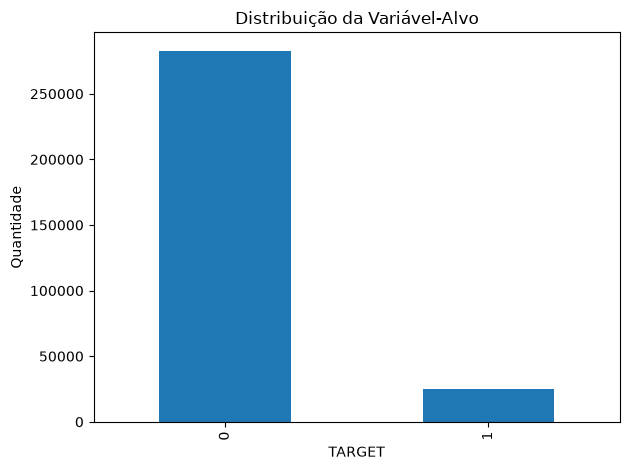

In [6]:
target_distribution = (
    application['TARGET']
    .value_counts()
    .sort_index()
    .rename('quantidade')
    .to_frame()
)
target_distribution['proporcao'] = (
    target_distribution['quantidade'] / len(application)
)
target_distribution['percentual'] = (
    target_distribution['proporcao'] * 100
)

display(target_distribution)

target_distribution['quantidade'].plot(kind='bar')
plt.title('Distribuição da Variável-Alvo')
plt.xlabel('TARGET')
plt.ylabel('Quantidade')
plt.tight_layout()
target_distribution_path = FIGURES_PATH / 'target_distribution.png'
plt.savefig(target_distribution_path)
plt.show()
plt.close()

Foram observadas 282.686 ocorrências de `TARGET = 0` (91,93%) e 24.825 de `TARGET = 1` (8,07%). A distribuição é desbalanceada, mas nenhum balanceamento foi aplicado nesta etapa.

### 6.3 Valores Ausentes

,quantidade,percentual
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


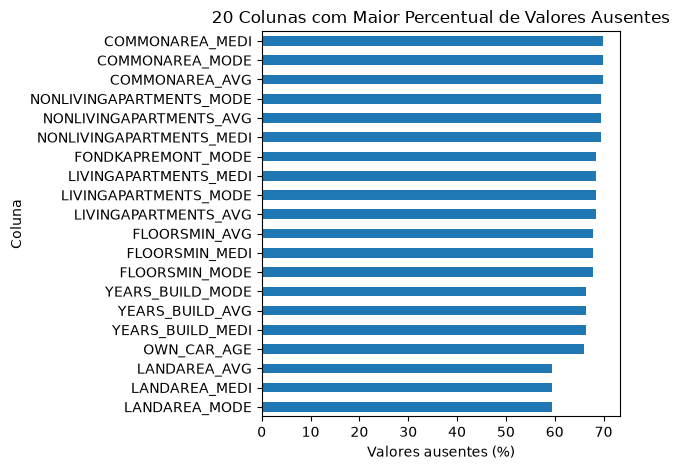

In [7]:
missing_values = pd.DataFrame({
    'quantidade': application.isna().sum(),
    'percentual': application.isna().mean() * 100,
})
top_missing_values = (
    missing_values.loc[missing_values['quantidade'] > 0]
    .nlargest(20, 'percentual')
)

display(top_missing_values)

top_missing_values.sort_values('percentual').plot.barh(
    y='percentual',
    legend=False,
)
plt.title('20 Colunas com Maior Percentual de Valores Ausentes')
plt.xlabel('Valores ausentes (%)')
plt.ylabel('Coluna')
plt.tight_layout()
top_missing_values_path = FIGURES_PATH / 'top_missing_values.png'
plt.savefig(top_missing_values_path)
plt.show()
plt.close()

Nas 20 colunas exibidas, os percentuais de ausência variam de 59,38% a 69,87%. `COMMONAREA_AVG`, `COMMONAREA_MODE` e `COMMONAREA_MEDI` apresentam o maior percentual observado, de 69,87%; nenhum valor foi removido ou imputado.

### 6.4 Resumo das Variáveis Numéricas

In [8]:
numeric_columns_of_interest = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
]
available_numeric_columns = [
    column
    for column in numeric_columns_of_interest
    if column in application.columns
]
numeric_summary = application[available_numeric_columns].describe().T

display(numeric_summary)

if 'DAYS_EMPLOYED' in application.columns:
    special_days_employed_count = int(
        application['DAYS_EMPLOYED'].eq(365243).sum()
    )
    print(
        'Ocorrências do valor 365243 em DAYS_EMPLOYED: '
        f'{special_days_employed_count:,}'
    )
else:
    print('A coluna DAYS_EMPLOYED não está presente na base.')

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
CNT_FAM_MEMBERS,307509.0,2.152665,0.910682,1.0,2.0,2.0,3.0,20.0


Ocorrências do valor 365243 em DAYS_EMPLOYED: 55,374


As oito variáveis numéricas selecionadas estão presentes na base. Em `DAYS_EMPLOYED`, o valor especial `365243` ocorre 55.374 vezes; ele foi apenas identificado, sem substituição ou limpeza.

### 6.5 Resumo das Variáveis Categóricas

In [9]:
categorical_columns = application.select_dtypes(
    include=['object', 'category', 'string']
).columns
categorical_rows = []

for column in categorical_columns:
    category_counts = application[column].value_counts(dropna=True)
    categorical_rows.append({
        'variavel': column,
        'categorias_distintas': application[column].nunique(dropna=True),
        'categoria_mais_frequente': (
            category_counts.index[0] if not category_counts.empty else pd.NA
        ),
        'frequencia_categoria_mais_frequente': (
            int(category_counts.iloc[0]) if not category_counts.empty else 0
        ),
        'valores_ausentes': int(application[column].isna().sum()),
    })

categorical_summary = (
    pd.DataFrame(
        categorical_rows,
        columns=[
            'variavel',
            'categorias_distintas',
            'categoria_mais_frequente',
            'frequencia_categoria_mais_frequente',
            'valores_ausentes',
        ],
    )
    .set_index('variavel')
    .sort_values('categorias_distintas', kind='stable')
    .head(20)
)

display(categorical_summary)

,categorias_distintas,categoria_mais_frequente,frequencia_categoria_mais_frequente,valores_ausentes
variavel,,,,
NAME_CONTRACT_TYPE,2,Cash loans,278232,0
FLAG_OWN_CAR,2,N,202924,0
FLAG_OWN_REALTY,2,Y,213312,0
EMERGENCYSTATE_MODE,2,No,159428,145755
CODE_GENDER,3,F,202448,0
HOUSETYPE_MODE,3,block of flats,150503,154297
FONDKAPREMONT_MODE,4,reg oper account,73830,210295
NAME_EDUCATION_TYPE,5,Secondary / secondary special,218391,0
NAME_FAMILY_STATUS,6,Married,196432,0


Foram identificadas 16 variáveis categóricas, com 2 a 58 categorias distintas. A tabela mostra todas elas por estarem dentro do limite de 20 e evidencia que algumas possuem valores ausentes; nenhuma codificação ou agregação foi aplicada.

### 6.6 Relação entre as Variáveis e a Variável-Alvo

Esta subseção investiga associações entre as variáveis numéricas e `TARGET`.

Como `TARGET` é binária, a correlação de Pearson entre uma variável e `TARGET` corresponde à correlação ponto-bisserial e serve como medida preliminar da associação linear entre a variável e a classe de dificuldade de pagamento.

A análise contempla:

1. as variáveis mais correlacionadas com `TARGET`;
2. pares de variáveis com correlação muito alta entre si, indicando redundância;
3. um mapa de calor com as variáveis mais relevantes.

Como a base ainda contém valores ausentes nesta etapa, cada correlação é calculada com as observações disponíveis para o par em questão (eliminação por pares).

,correlacao
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994
FLAG_EMP_PHONE,0.045982


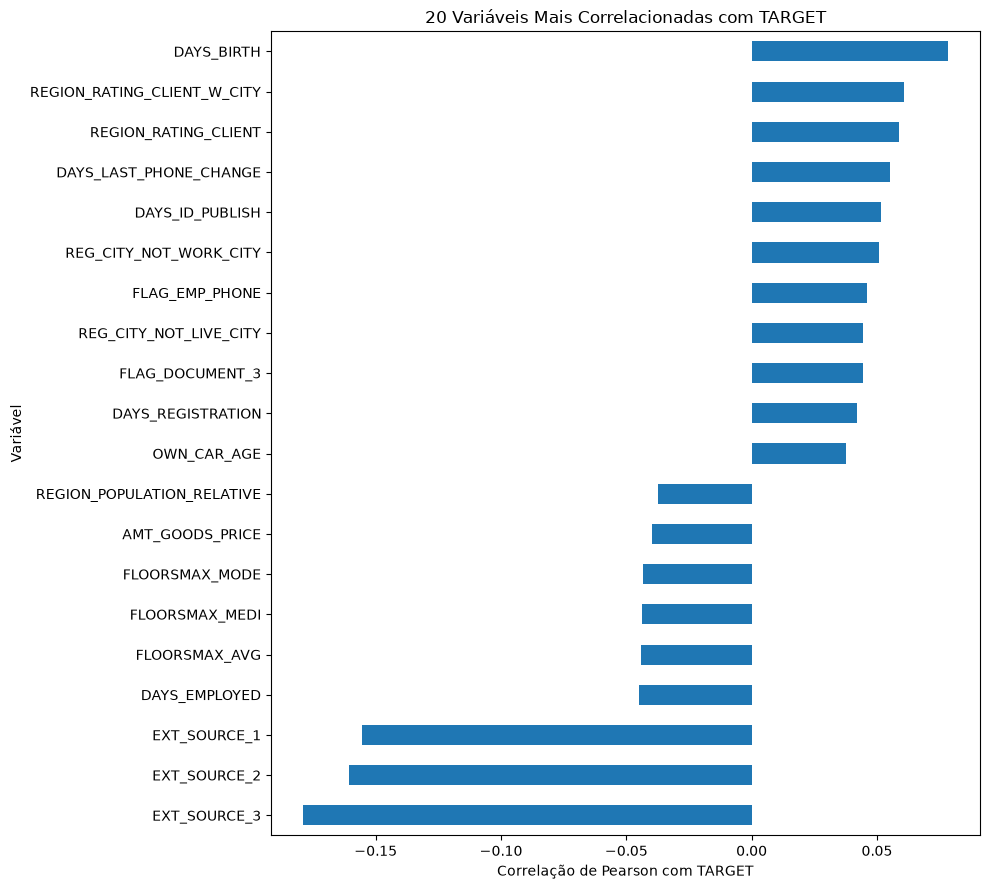

In [10]:
numeric_columns = application.select_dtypes(include=np.number).columns
numeric_columns = numeric_columns.drop(['TARGET', 'SK_ID_CURR'], errors='ignore')

corr_with_target = (
    application[numeric_columns]
    .corrwith(application['TARGET'])
    .rename('correlacao')
    .to_frame()
)
corr_with_target['correlacao_abs'] = corr_with_target['correlacao'].abs()
corr_with_target = corr_with_target.sort_values(
    'correlacao_abs',
    ascending=False,
)

top_corr_with_target = corr_with_target.head(20).copy()
display(top_corr_with_target.drop(columns='correlacao_abs'))

top_corr_with_target['correlacao'].sort_values().plot.barh(figsize=(10, 9))
plt.title('20 Variáveis Mais Correlacionadas com TARGET')
plt.xlabel('Correlação de Pearson com TARGET')
plt.ylabel('Variável')
plt.tight_layout()
corr_with_target_path = FIGURES_PATH / 'correlation_with_target.png'
plt.savefig(corr_with_target_path)
plt.show()
plt.close()

,variavel_a,variavel_b,correlacao
10,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.998495
45,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998490
20,FLOORSMIN_AVG,FLOORSMIN_MEDI,0.997241
18,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.997034
16,ENTRANCES_AVG,ENTRANCES_MEDI,0.996886
14,ELEVATORS_AVG,ELEVATORS_MEDI,0.996099
12,COMMONAREA_AVG,COMMONAREA_MEDI,0.995978
26,LIVINGAREA_AVG,LIVINGAREA_MEDI,0.995596
4,APARTMENTS_AVG,APARTMENTS_MEDI,0.995081
6,BASEMENTAREA_AVG,BASEMENTAREA_MEDI,0.994317


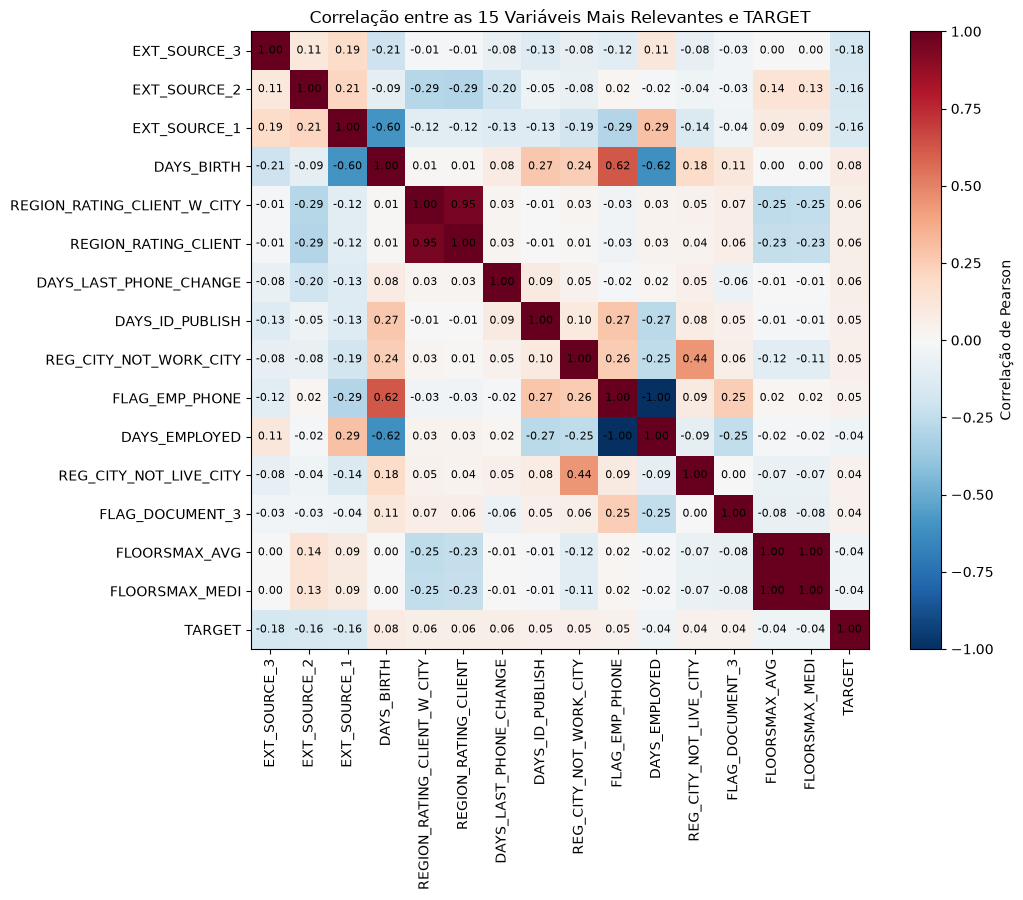

In [11]:
correlation_matrix = application[numeric_columns].corr()

corr_threshold = 0.95
upper_triangle = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape, dtype=bool),
            k=1,
        )
    )
)

stacked_pairs = upper_triangle.stack()
high_correlation_pairs = (
    stacked_pairs[stacked_pairs.abs() >= corr_threshold]
    .rename('correlacao')
    .reset_index()
    .rename(
        columns={
            'level_0': 'variavel_a',
            'level_1': 'variavel_b',
        },
    )
    .sort_values('correlacao', ascending=False)
)

display(high_correlation_pairs)

top_features = corr_with_target.head(15).index.tolist()
subset_correlation = application[top_features + ['TARGET']].corr()

plt.figure(figsize=(11, 9))
plt.imshow(subset_correlation, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Correlação de Pearson')
plt.xticks(
    ticks=range(len(subset_correlation)),
    labels=subset_correlation.columns,
    rotation=90,
)
plt.yticks(
    ticks=range(len(subset_correlation)),
    labels=subset_correlation.index,
)

for i in range(len(subset_correlation)):
    for j in range(len(subset_correlation)):
        value = subset_correlation.iloc[i, j]
        plt.text(
            j,
            i,
            f'{value:.2f}',
            ha='center',
            va='center',
            fontsize=8,
        )

plt.title('Correlação entre as 15 Variáveis Mais Relevantes e TARGET')
plt.tight_layout()
subset_corr_path = FIGURES_PATH / 'correlation_top_features.png'
plt.savefig(subset_corr_path)
plt.show()
plt.close()

As três variáveis mais correlacionadas com `TARGET` foram `EXT_SOURCE_3` (-0.1789), `EXT_SOURCE_2` (-0.1605) e `EXT_SOURCE_1` (-0.1553): pontuações externas de risco menores estão associadas a maior chance de dificuldade de pagamento. Em seguida aparecem `DAYS_BIRTH` (0.0782), `REGION_RATING_CLIENT_W_CITY` (0.0609) e `REGION_RATING_CLIENT` (0.0589).

Como `DAYS_BIRTH` é contado em dias e é negativo, a correlação positiva de 0.0782 indica que solicitantes mais jovens apresentam maior associação com a classe de dificuldade de pagamento. A correlação de `DAYS_EMPLOYED` (-0.0449) deve ser interpretada com cautela, pois a média dessa variável é distorcida pelo valor especial `365243` identificado na seção 6.4.

Na análise de redundância, foram identificados 46 pares com correlação igual ou superior a 0.95, formados principalmente pelos conjuntos `*_AVG`, `*_MODE` e `*_MEDI` das mesmas variáveis de moradia. Isso indica que apenas uma representação de cada conjunto deve ser mantida na seção 7. Destacam-se ainda `DAYS_EMPLOYED` com `FLAG_EMP_PHONE` (-0.9998), quase perfeitamente correlacionados, e `AMT_CREDIT` com `AMT_GOODS_PRICE` (0.9870), além de `REGION_RATING_CLIENT` com `REGION_RATING_CLIENT_W_CITY` (0.9508).

Como os valores refletem os dados brutos, com eliminação por pares de valores ausentes, eles serão reconsiderados após o tratamento definido nas seções 7 a 10.

### 6.7 Comparação das Classes da Variável-Alvo

Esta subseção compara a distribuição das principais variáveis numéricas entre `TARGET = 0` e `TARGET = 1`, buscando evidências descritivas de diferenças entre os dois grupos.

In [12]:
comparison_columns = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
]
available_comparison = [
    column
    for column in comparison_columns
    if column in application.columns
]

comparison_rows = []
for column in available_comparison:
    grouped = application.groupby('TARGET')[column]
    for target_value in [0, 1]:
        series = grouped.get_group(target_value)
        comparison_rows.append({
            'variavel': column,
            'TARGET': target_value,
            'observacoes': int(series.notna().sum()),
            'media': series.mean(),
            'mediana': series.median(),
        })

comparison_summary = (
    pd.DataFrame(comparison_rows)
    .set_index(['variavel', 'TARGET'])
)

display(comparison_summary)

observacoes          media        mediana
variavel         TARGET                                           
AMT_INCOME_TOTAL 0            282686  169077.722266  148500.000000
                 1             24825  165611.760906  135000.000000
AMT_CREDIT       0            282686  602648.282002  517788.000000
                 1             24825  557778.527674  497520.000000
AMT_ANNUITY      0            282674   27163.623349   24876.000000
                 1             24825   26481.744290   25263.000000
AMT_GOODS_PRICE  0            282429  542736.795003  450000.000000
                 1             24804  488972.412554  450000.000000
DAYS_BIRTH       0            282686  -16138.176397  -15877.000000
                 1             24825  -14884.828077  -14282.000000
DAYS_EMPLOYED    0            282686   65696.146123   -1235.000000
                 1             24825   42394.675448   -1034.000000
EXT_SOURCE_1     0            124079       0.511461       0.517452
                 1             10054       0.386968       0.361675
EXT_SOURCE_2     0            282078       0.523479       0.573905
                 1             24773       0.410935       0.440381
EXT_SOURCE_3     0            227398       0.520969       0.546023
                 1             19148       0.390717       0.379100

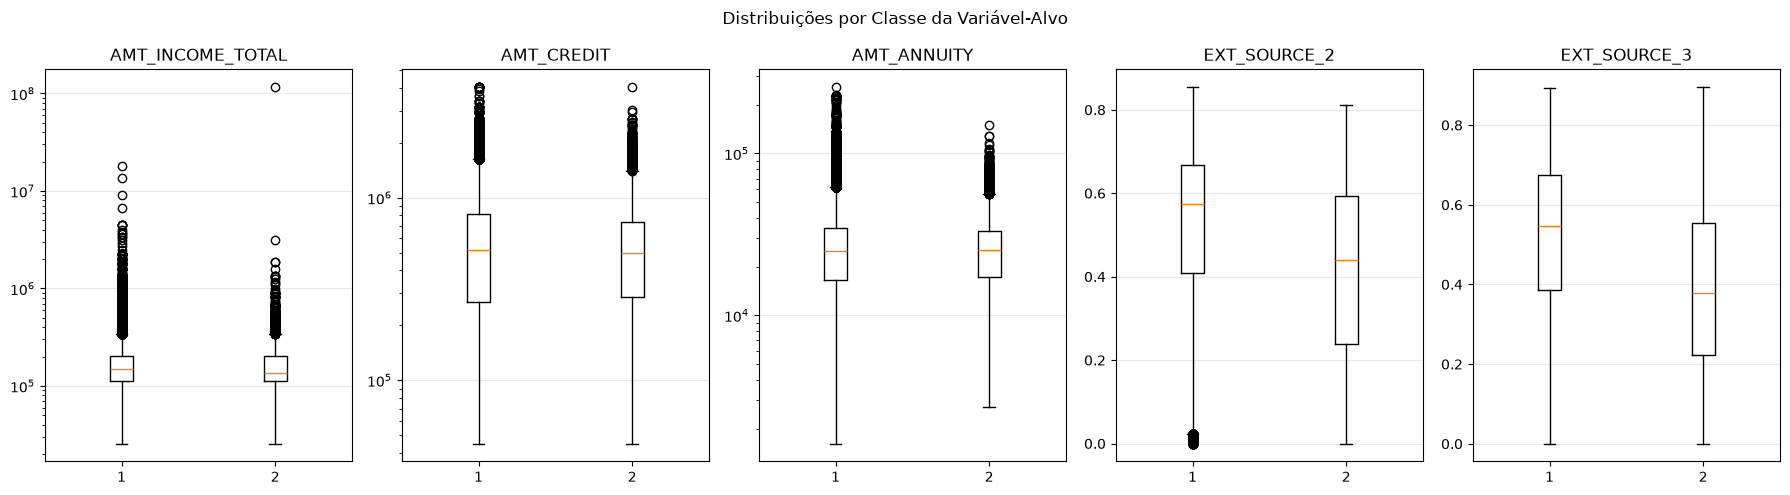

In [14]:
boxplot_columns = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
]
available_boxplot = [
    column
    for column in boxplot_columns
    if column in application.columns
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(available_boxplot),
    figsize=(18, 5),
    squeeze=False,
)

for ax, column in zip(axes.ravel(), available_boxplot):
    plot_data = application[['TARGET', column]].dropna()
    groups = [
        plot_data.loc[plot_data['TARGET'] == 0, column],
        plot_data.loc[plot_data['TARGET'] == 1, column],
    ]
    ax.boxplot(groups, label=['TARGET = 0', 'TARGET = 1'])
    if column.startswith('AMT_'):
        ax.set_yscale('log')
    ax.set_title(column)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribuições por Classe da Variável-Alvo')
plt.tight_layout()
boxplot_path = FIGURES_PATH / 'target_comparison_boxplots.png'
plt.savefig(boxplot_path)
plt.show()
plt.close()

Os solicitantes da classe `TARGET = 1` apresentam, em mediana, renda menor (R$ 135.000 contra R$ 148.500) e idade menor (aproximadamente 39,1 anos contra 43,5 anos). As três pontuações externas apresentam diferenças marcantes: a mediana de `EXT_SOURCE_3` é 0,379 para `TARGET = 1` e 0,546 para `TARGET = 0`, padrão que se repete em `EXT_SOURCE_1` e `EXT_SOURCE_2`. Valores de pontuação externa mais baixos indicam maior risco.

O tempo mediano de emprego (`DAYS_EMPLOYED`) é ligeiramente menor na classe positiva (-1.034 dias contra -1.235 dias), embora a média da variável seja distorcida pelo valor especial `365243` e não deva ser comparada diretamente. A mediana do valor solicitado é levemente menor para `TARGET = 1` (R$ 497.520 contra R$ 517.788), e a parcela mediana é semelhante entre as classes.

Essas diferenças são descritivas e não controlam outros fatores; a importância preditiva real será avaliada pelos modelos.

### 6.8 Ausência de Informação e Taxa de Dificuldade por Categoria

Esta subseção investiga se a ausência de informações se associa a `TARGET` e como a taxa da classe positiva varia entre as categorias das principais variáveis categóricas.

In [15]:
columns_with_missing = numeric_columns[
    application[numeric_columns].isna().sum() > 0
]

missing_signal = (
    application[columns_with_missing]
    .isna()
    .corrwith(application['TARGET'])
    .rename('correlacao')
    .to_frame()
    .sort_values('correlacao', ascending=False)
)

display(missing_signal.head(15))

C:\Users\Milena\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Milena\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,correlacao
TOTALAREA_MODE,0.041168
ENTRANCES_MODE,0.040872
ENTRANCES_AVG,0.040872
ENTRANCES_MEDI,0.040872
FLOORSMAX_MODE,0.040847
FLOORSMAX_AVG,0.040847
FLOORSMAX_MEDI,0.040847
YEARS_BEGINEXPLUATATION_MODE,0.040554
YEARS_BEGINEXPLUATATION_AVG,0.040554
YEARS_BEGINEXPLUATATION_MEDI,0.040554


In [16]:
target_rate_columns = [
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_INCOME_TYPE',
]
available_rate_columns = [
    column
    for column in target_rate_columns
    if column in application.columns
]

for column in available_rate_columns:
    default_rate = (
        application[[column, 'TARGET']]
        .groupby(column)['TARGET']
        .agg(['count', 'mean'])
        .rename(columns={'count': 'quantidade', 'mean': 'taxa_target_1'})
        .query('quantidade >= 1000')
        .sort_values('taxa_target_1', ascending=False)
    )
    print(f'--- {column} ---')
    display(default_rate)

--- NAME_CONTRACT_TYPE ---


,quantidade,taxa_target_1
NAME_CONTRACT_TYPE,,
Cash loans,278232,0.083459
Revolving loans,29279,0.054783


--- CODE_GENDER ---


,quantidade,taxa_target_1
CODE_GENDER,,
M,105059,0.101419
F,202448,0.069993


--- NAME_EDUCATION_TYPE ---


,quantidade,taxa_target_1
NAME_EDUCATION_TYPE,,
Lower secondary,3816,0.109277
Secondary / secondary special,218391,0.089399
Incomplete higher,10277,0.084850
Higher education,74863,0.053551


--- NAME_FAMILY_STATUS ---


,quantidade,taxa_target_1
NAME_FAMILY_STATUS,,
Civil marriage,29775,0.099446
Single / not married,45444,0.098077
Separated,19770,0.081942
Married,196432,0.075599
Widow,16088,0.058242


--- NAME_INCOME_TYPE ---


,quantidade,taxa_target_1
NAME_INCOME_TYPE,,
Working,158774,0.095885
Commercial associate,71617,0.074843
State servant,21703,0.057550
Pensioner,55362,0.053864


Para variáveis como `TOTALAREA_MODE`, `ENTRANCES_*` e `FLOORSMAX_*`, a própria ausência de informação apresenta correlação pequena, mas positiva, com `TARGET` (cerca de 0.040). Isso indica que o fato de determinadas informações de moradia não terem sido preenchidas tem associação leve com a classe de dificuldade de pagamento, o que justifica avaliar indicadores de ausência na seção 7.

Entre as variáveis categóricas, as maiores taxas de `TARGET = 1` foram observadas em contratos do tipo Cash loans (8,35%, contra 5,48% em Revolving loans), em solicitantes do sexo masculino (10,14%, contra 7,00% no feminino) e entre quem possui menor escolaridade (10,93% em Lower secondary, contra 5,36% em Higher education), com padrão monotônico: quanto menor a escolaridade, maior a taxa de dificuldade. Por tipo de renda, trabalhadores assalariados do setor privado (Working) apresentam a maior taxa (9,59%), enquanto pensionistas (5,39%) apresentam a menor.

Esses resultados são descritivos e serão consolidados nas decisões das seções 7 a 10.

## 7. Limpeza dos Dados e Engenharia de Atributos

## 8. Construção de X e y

## 9. Divisão em Treinamento, Validação e Teste

## 10. Pré-processamento dos Dados

## 11. Rede Neural

## 12. Árvore de Decisão e Poda por Complexidade de Custo

## 13. Comparação dos Modelos

## 14. Conclusões